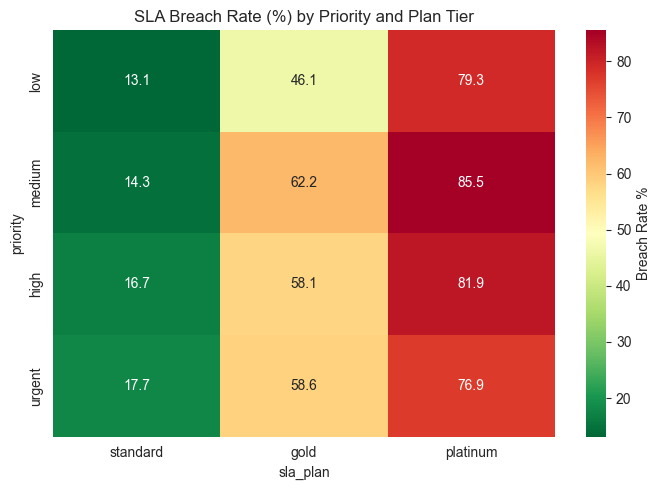

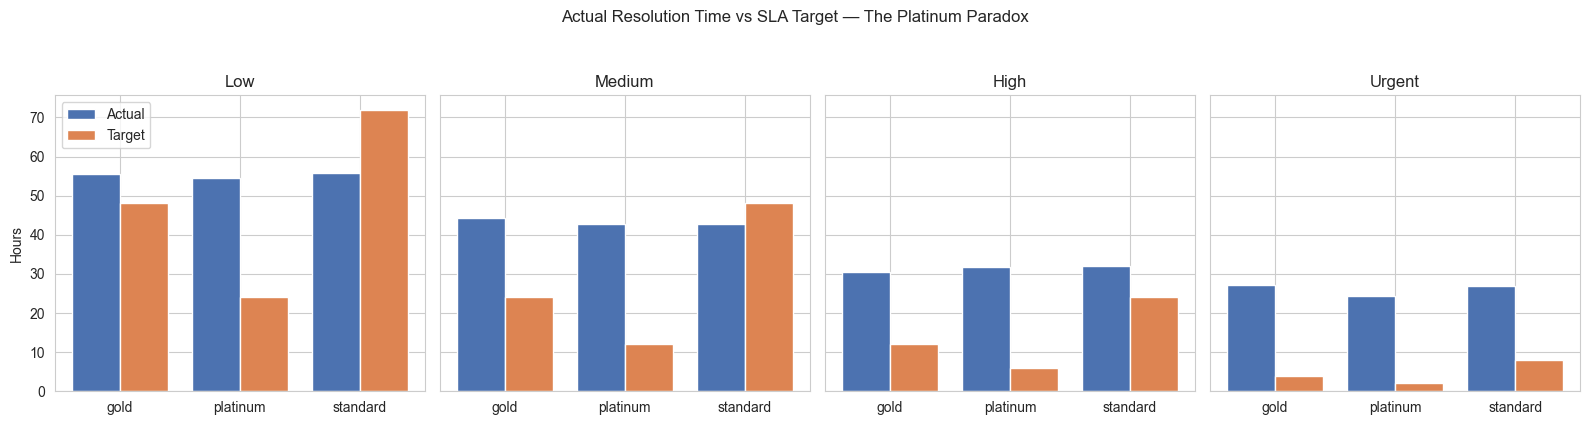

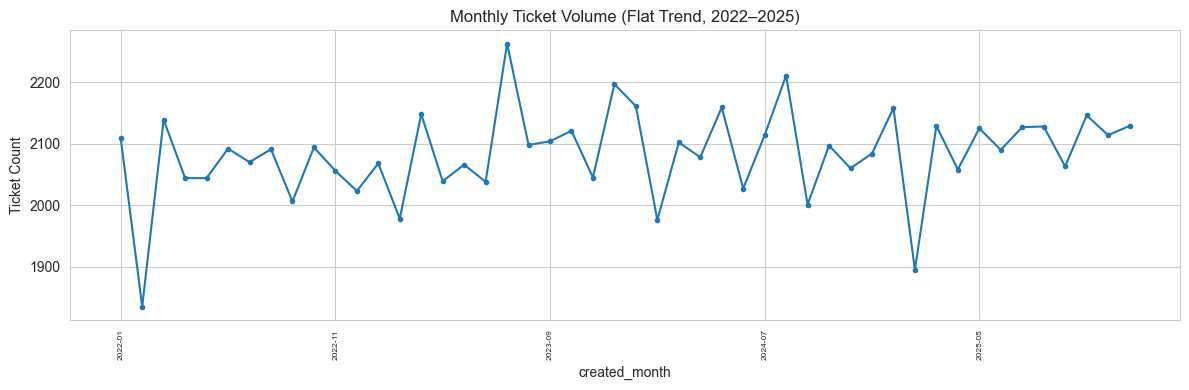

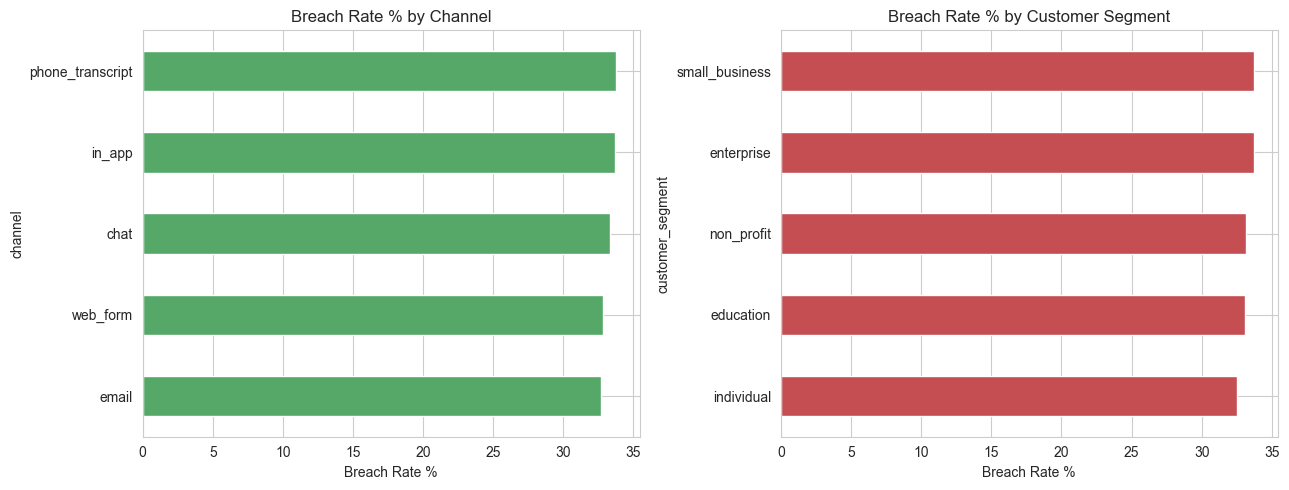

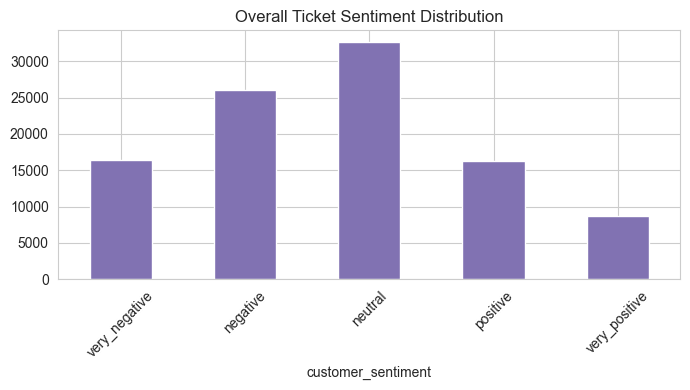

Overall breach rate: 33.3 %

Breach rate by channel:
 channel
chat                33.3
email               32.7
in_app              33.7
phone_transcript    33.8
web_form            32.8
Name: sla_breached, dtype: float64

Breach rate by segment:
 customer_segment
education         33.1
enterprise        33.7
individual        32.5
non_profit        33.2
small_business    33.7
Name: sla_breached, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../Dataset/Cleaned/support_tickets_cleaned.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
terminal = df[df['is_terminal'] == True].copy()

# --- 1. Breach rate heatmap: priority x plan ---
pivot = terminal.pivot_table(
    values='sla_breached', index='priority', columns='sla_plan', aggfunc='mean'
) * 100
priority_order = ['low', 'medium', 'high', 'urgent']
pivot = pivot.reindex(priority_order)[['standard', 'gold', 'platinum']]

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Breach Rate %'})
plt.title('SLA Breach Rate (%) by Priority and Plan Tier')
plt.tight_layout()
plt.savefig('../Images/EDA/breach_rate_heatmap.png')
plt.show()

# --- 2. The platinum paradox: actual resolution time vs target, by plan ---
comparison = terminal.groupby(['sla_plan', 'priority']).agg(
    avg_resolution=('resolution_time_hours', 'mean'),
    avg_target=('sla_target_hours', 'mean')
).reset_index()
comparison['priority'] = pd.Categorical(comparison['priority'], categories=priority_order, ordered=True)
comparison = comparison.sort_values(['priority', 'sla_plan'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, p in zip(axes, priority_order):
    sub = comparison[comparison['priority'] == p]
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub['avg_resolution'], width=0.4, label='Actual', color='#4C72B0')
    ax.bar(x + 0.2, sub['avg_target'], width=0.4, label='Target', color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['sla_plan'])
    ax.set_title(p.capitalize())
    if p == 'low':
        ax.set_ylabel('Hours')
fig.suptitle('Actual Resolution Time vs SLA Target — The Platinum Paradox', y=1.05)
axes[0].legend()
plt.tight_layout()
plt.savefig('../Images/EDA/platinum_paradox.png')
plt.show()

# --- 3. Monthly ticket volume trend ---
monthly = df.groupby('created_month').size()
plt.figure(figsize=(12, 4))
monthly.plot(marker='o', markersize=3)
plt.title('Monthly Ticket Volume (Flat Trend, 2022–2025)')
plt.ylabel('Ticket Count')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('../Images/EDA/monthly_volume_trend.png')
plt.show()

# --- 4. Breach rate by channel and customer segment ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
terminal.groupby('channel')['sla_breached'].mean().mul(100).sort_values().plot(
    kind='barh', ax=axes[0], color='#55A868'
)
axes[0].set_title('Breach Rate % by Channel')
axes[0].set_xlabel('Breach Rate %')

terminal.groupby('customer_segment')['sla_breached'].mean().mul(100).sort_values().plot(
    kind='barh', ax=axes[1], color='#C44E52'
)
axes[1].set_title('Breach Rate % by Customer Segment')
axes[1].set_xlabel('Breach Rate %')
plt.tight_layout()
plt.savefig('../Images/EDA/breach_by_channel_segment.png')
plt.show()

# --- 5. Sentiment distribution overall (confirms it's intake-driven, not outcome-driven) ---
plt.figure(figsize=(7, 4))
sentiment_order = ['very_negative', 'negative', 'neutral', 'positive', 'very_positive']
df['customer_sentiment'].value_counts().reindex(sentiment_order).plot(kind='bar', color='#8172B2')
plt.title('Overall Ticket Sentiment Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../Images/EDA/sentiment_distribution.png')
plt.show()

# Print key numbers for the report
print("Overall breach rate:", round(terminal['sla_breached'].mean() * 100, 1), "%")
print("\nBreach rate by channel:\n", terminal.groupby('channel')['sla_breached'].mean().mul(100).round(1))
print("\nBreach rate by segment:\n", terminal.groupby('customer_segment')['sla_breached'].mean().mul(100).round(1))

Modeling rows: 60113
Train breach rate: 0.333  | Test breach rate: 0.333

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      8025
           1       0.61      0.57      0.59      3998

    accuracy                           0.74     12023
   macro avg       0.70      0.70      0.70     12023
weighted avg       0.73      0.74      0.74     12023

ROC-AUC: 0.756

--- Random Forest (unweighted) ---
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      8025
           1       0.66      0.59      0.62      3998

    accuracy                           0.76     12023
   macro avg       0.73      0.72      0.73     12023
weighted avg       0.76      0.76      0.76     12023

ROC-AUC: 0.776

--- Random Forest (class_weight='balanced') ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      8025
           1       0

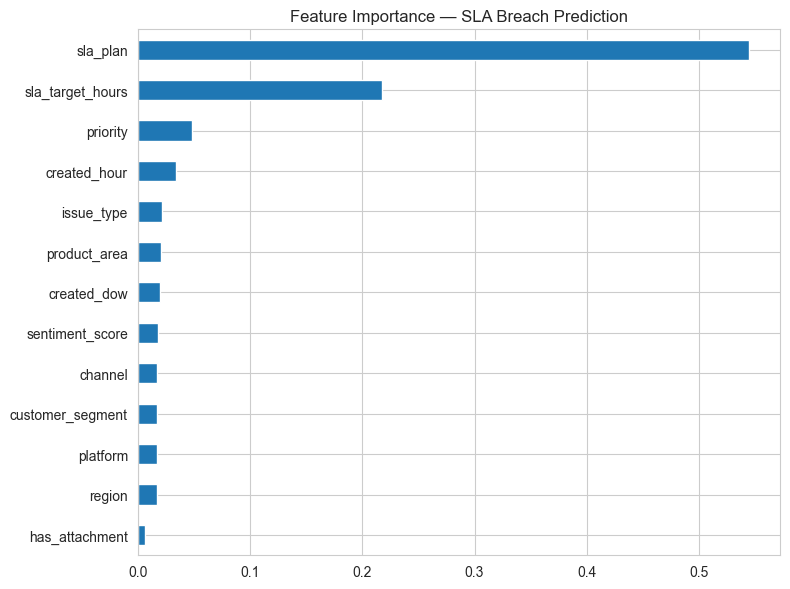

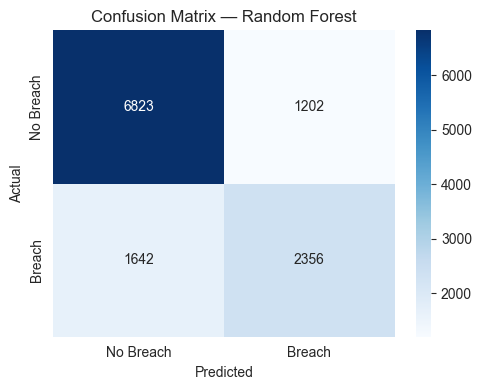


Model saved to Models/sla_breach_model.pkl


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('../Dataset/Cleaned/support_tickets_cleaned.csv')
df['created_at'] = pd.to_datetime(df['created_at'])

# --- 1. Filter to terminal tickets (breach is only defined here) ---
model_df = df[df['is_terminal'] == True].copy()
print("Modeling rows:", model_df.shape[0])

# --- 2. Feature selection: ONLY creation-time-known fields ---
features = [
    'priority', 'sla_plan', 'sla_target_hours', 'product_area', 'issue_type',
    'channel', 'customer_segment', 'region', 'platform',
    'has_attachment', 'sentiment_score', 'created_hour', 'created_dow'
]
target = 'sla_breached'

X = model_df[features].copy()
y = model_df[target].astype(int)

# --- 3. Encode categoricals ---
cat_features = ['priority', 'sla_plan', 'product_area', 'issue_type',
                 'channel', 'customer_segment', 'region', 'platform', 'created_dow']
encoders = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train breach rate:", y_train.mean().round(3), " | Test breach rate:", y_test.mean().round(3))

# --- 5. Baseline: Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
print("\n--- Logistic Regression ---")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 3))

# --- 6. Random Forest (no class_weight first) ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("\n--- Random Forest (unweighted) ---")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 3))

# --- 7. Random Forest with class_weight='balanced' for comparison ---
rf_bal = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_bal.fit(X_train, y_train)
rf_bal_pred = rf_bal.predict(X_test)
rf_bal_proba = rf_bal.predict_proba(X_test)[:, 1]
print("\n--- Random Forest (class_weight='balanced') ---")
print(classification_report(y_test, rf_bal_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_bal_proba), 3))

# --- 8. Feature importance (best model — pick after comparing above) ---
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances:\n", importances)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance — SLA Breach Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../Images/Model/feature_importance.png')
plt.show()

# --- 9. Confusion matrix for chosen model ---
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Breach', 'Breach'], yticklabels=['No Breach', 'Breach'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../Images/Model/confusion_matrix.png')
plt.show()

# --- 10. Save model + encoders ---
joblib.dump(rf, '../Models/sla_breach_model.pkl')
joblib.dump(encoders, '../Models/label_encoders.pkl')
print("\nModel saved to Models/sla_breach_model.pkl")